In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
with open('data/1.json') as f:
    cross_raw = json.load(f)

abbrev = {
    'GEN':'Genesis','EXO':'Exodus','LEV':'Leviticus','NUM':'Numbers','DEU':'Deuteronomy',
    'JOS':'Joshua','JDG':'Judges','RUT':'Ruth','1SA':'1 Samuel','2SA':'2 Samuel',
    '1KI':'1 Kings','2KI':'2 Kings','1CH':'1 Chronicles','2CH':'2 Chronicles',
    'EZR':'Ezra','NEH':'Nehemiah','EST':'Esther','JOB':'Job','PSA':'Psalms',
    'PRO':'Proverbs','ECC':'Ecclesiastes','SON':'Song of Solomon','ISA':'Isaiah',
    'JER':'Jeremiah','LAM':'Lamentations','EZE':'Ezekiel','DAN':'Daniel',
    'HOS':'Hosea','JOE':'Joel','AMO':'Amos','OBA':'Obadiah','JON':'Jonah',
    'MIC':'Micah','NAH':'Nahum','HAB':'Habakkuk','ZEP':'Zephaniah','HAG':'Haggai',
    'ZEC':'Zechariah','MAL':'Malachi','MAT':'Matthew','MAR':'Mark','LUK':'Luke',
    'JOH':'John','ACT':'Acts','ROM':'Romans','1CO':'1 Corinthians','2CO':'2 Corinthians',
    'GAL':'Galatians','EPH':'Ephesians','PHP':'Philippians','COL':'Colossians',
    '1TH':'1 Thessalonians','2TH':'2 Thessalonians','1TI':'1 Timothy','2TI':'2 Timothy',
    'TIT':'Titus','PHM':'Philemon','HEB':'Hebrews','JAM':'James','1PE':'1 Peter',
    '2PE':'2 Peter','1JO':'1 John','2JO':'2 John','3JO':'3 John','JDE':'Jude','REV':'Revelation'
}

# Build one basket per Genesis verse
transactions = []
for entry in cross_raw.values():
    if isinstance(entry, dict) and 'r' in entry:
        books = list({ref.split()[0] for ref in entry['r'].values()})
        if len(books) >= 2:
            transactions.append([abbrev.get(b, b) for b in books])

print(f'Transactions (Genesis verses): {len(transactions)}')
print(f'Sample basket (Genesis 1:1)   : {transactions[0]}')

Transactions (Genesis verses): 837
Sample basket (Genesis 1:1)   : ['Ephesians', 'Psalms', '2 Kings', '2 Chronicles', 'Ecclesiastes', 'Nehemiah', 'Isaiah', 'Job', 'Proverbs', 'Romans', 'Revelation', 'John', 'Mark', '1 John', 'Hebrews', 'Jeremiah', '1 Chronicles', 'Zechariah', '2 Peter', '1 Corinthians', 'Acts', 'Exodus', 'Matthew', 'Colossians']


In [3]:
te = TransactionEncoder()
encoded = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)

freq = fpgrowth(encoded, min_support=0.10, use_colnames=True)
freq['length'] = freq['itemsets'].apply(len)
freq['label']  = freq['itemsets'].apply(lambda s: ', '.join(sorted(s)))
freq = freq.sort_values('support', ascending=False)

# Show single-book support
freq[freq.length == 1][['label', 'support']].head(10).rename(columns={'label': 'Book'})

,Book,support
12,Genesis,0.870968
0,Psalms,0.410992
1,Isaiah,0.292712
2,Exodus,0.240143
13,Deuteronomy,0.207885
3,Matthew,0.204301
20,1 Samuel,0.198327
4,Job,0.195938
5,Hebrews,0.194743
7,Jeremiah,0.191159


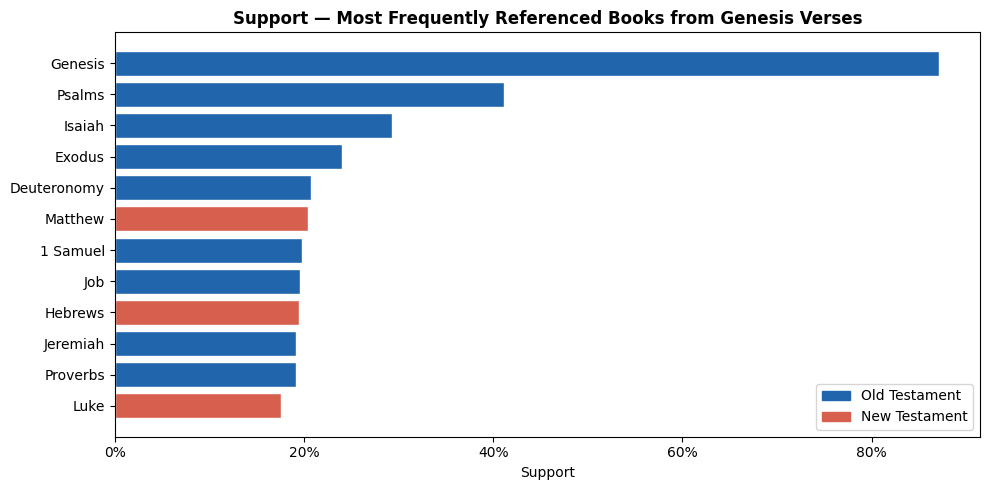

In [4]:
single = freq[freq.length == 1].copy()
single['book'] = single['itemsets'].apply(lambda s: list(s)[0])
top = single.nlargest(12, 'support')

OT = set(list(abbrev.values())[:39])
colors = ['#2166ac' if b in OT else '#d6604d' for b in top['book']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top['book'], top['support'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xlabel('Support')
ax.set_title('Support — Most Frequently Referenced Books from Genesis Verses', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2166ac', label='Old Testament'),
    mpatches.Patch(color='#d6604d', label='New Testament')
])
plt.tight_layout()
plt.show()

In [5]:
rules = association_rules(freq, metric='lift', min_threshold=1.2)
rules = rules.sort_values('confidence', ascending=False).reset_index(drop=True)
rules['antecedent'] = rules['antecedents'].apply(lambda s: ' + '.join(sorted(s)))
rules['consequent'] = rules['consequents'].apply(lambda s: ' + '.join(sorted(s)))

rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']].head(10)

,antecedent,consequent,support,confidence,lift
0,Job,Psalms,0.125448,0.640244,1.557803
1,Genesis + Job,Psalms,0.107527,0.633803,1.542131
2,Jeremiah,Psalms,0.109916,0.575000,1.399055
3,Genesis + Isaiah,Psalms,0.139785,0.570732,1.388670
4,Isaiah,Psalms,0.164875,0.563265,1.370503
5,Hebrews,Psalms,0.108722,0.558282,1.358379
6,Jeremiah,Isaiah,0.106332,0.556250,1.900332
7,Exodus + Genesis,Psalms,0.118280,0.550000,1.338227
8,Job,Genesis + Psalms,0.107527,0.548780,1.526011
9,Matthew,Psalms,0.111111,0.543860,1.323286


In [6]:
rules_lift = rules.sort_values('lift', ascending=False).reset_index(drop=True)
rules_lift[['antecedent', 'consequent', 'support', 'confidence', 'lift']].head(10)

,antecedent,consequent,support,confidence,lift
0,Isaiah,Jeremiah,0.106332,0.363265,1.900332
1,Jeremiah,Isaiah,0.106332,0.556250,1.900332
2,Psalms,Job,0.125448,0.305233,1.557803
3,Job,Psalms,0.125448,0.640244,1.557803
4,Genesis + Job,Psalms,0.107527,0.633803,1.542131
5,Psalms,Genesis + Job,0.107527,0.261628,1.542131
6,Genesis + Psalms,Job,0.107527,0.299003,1.526011
7,Job,Genesis + Psalms,0.107527,0.548780,1.526011
8,Jeremiah,Psalms,0.109916,0.575000,1.399055
9,Psalms,Jeremiah,0.109916,0.267442,1.399055


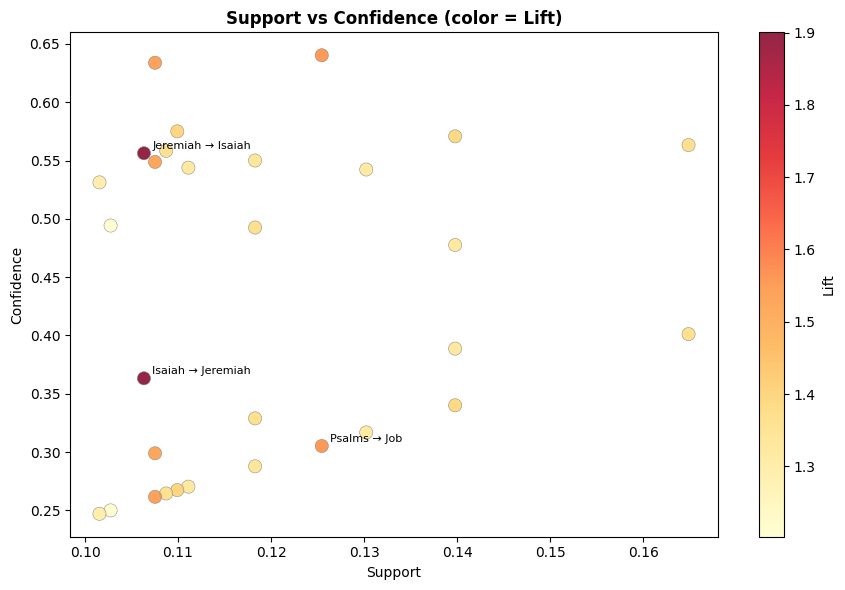

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd', s=90, alpha=0.85,
    edgecolors='grey', linewidth=0.4
)
plt.colorbar(sc, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Support vs Confidence (color = Lift)', fontweight='bold')
for _, row in rules_lift.head(3).iterrows():
    ax.annotate(
        f"{row['antecedent']} → {row['consequent']}",
        xy=(row['support'], row['confidence']),
        fontsize=8, xytext=(6, 3), textcoords='offset points'
    )
plt.tight_layout()
plt.show()